# Performance plots

John Curtin & Coco  
October 15, 2024

## Code status

Complete for use in GPS study as of 10/2024.

## Notes

Generates auROC plot.

## Set Up

### Study parameters

In [ ]:
study <- params$study
cv <- params$cv
algorithms <- params$algorithms
version <- params$version


### Defaults

In [ ]:

# handle conflicts
options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_ml.R?raw=true")


ℹ SHA-1 hash of file is "77e91675366f10788c6bcb59fa1cfc9ee0c75281"

### Packages for script

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'yardstick'

The following object is masked from 'package:readr':

    spec

ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

### Absolute paths

In [ ]:
path_models <- format_path(str_c("studydata/risk/models/", study))


> CP these are I think raw probabilities not beta – issue?

In [ ]:
probs <- # read_csv(here::here(path_models, str_c("inner_metrics_", version, "_", cv, ".csv"))) |> 
  read_rds(here::here(path_models, str_c("inner_preds_", version, "_", cv, ".rds"))) |> 
  #pivot_longer(cols = starts_with("prob"), 
               #names_to = "method", 
               #values_to = ".pred_Lapse") |>
  glimpse()


Rows: 312,174
Columns: 7
$ id_obs          <int> 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612,…
$ outer_split_num <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ inner_split_num <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ prob_raw        <dbl> 0.5004720, 0.4995192, 0.4995192, 0.5005576, 0.5005382,…
$ prob_iso        <dbl> 0.07657658, 0.07657658, 0.07657658, 0.07657658, 0.0765…
$ prob_logi       <dbl> 0.09117982, 0.09939817, 0.09939817, 0.09293282, 0.0923…
$ label           <fct> no lapse, no lapse, no lapse, no lapse, no lapse, no l…

In [ ]:
# CY: confusion over x and y axis

# roc_data <- probs |> 
#   roc_curve(prob_raw, truth = label)
#   
# roc_data |>
#   mutate(sensitivity = round(sensitivity, 4),
#          specificity = round(specificity, 4)) |>
#   group_by(sensitivity, specificity) |> 
#   summarise(.threshold = mean(.threshold)) |> 
#   ggplot(aes(x = 1 - specificity, y = sensitivity, color = .threshold)) +
#   geom_path(linewidth = 1) +
#   geom_abline(lty = 3) +
#   coord_fixed(xlim = c(0, 1), ylim = c(0, 1)) +
#   labs(x = "Specificity",
#        y = "Sensitivity") +
#   scale_x_continuous(breaks = seq(0,1,.25),
#     labels = sprintf("%.2f", seq(1,0,-.25))) +
#   scale_color_gradient(low="blue", high = "red") +
#   theme(axis.text = element_text(size = rel(1.50)), 
#         axis.title = element_text(size = rel(1.75)))


## Plots

`summarise()` has grouped output by 'tp'. You can override using the `.groups`
argument.

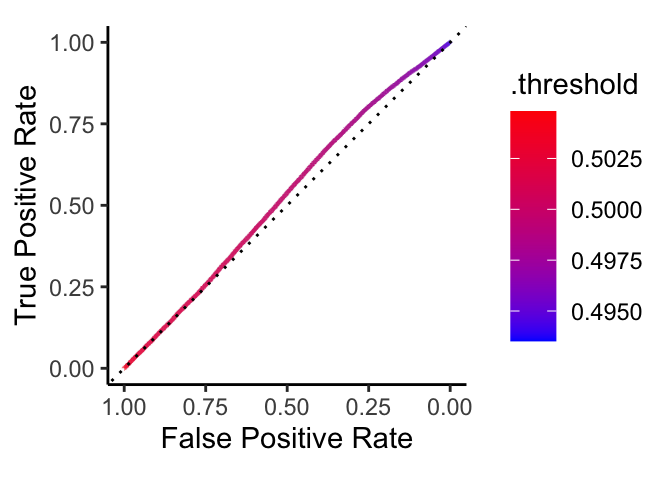

In [ ]:

tpfp_data <- probs |> 
  roc_curve(prob_raw, truth = label)
  
tpfp_data |>
  mutate(tp = round(sensitivity, 4),
         fp = round(1 - specificity, 4)) |>
  group_by(tp, fp) |> 
  summarise(.threshold = mean(.threshold)) |> 
  ggplot(aes(x = fp, y = tp, color = .threshold)) +
  geom_path(linewidth = 1) +
  geom_abline(lty = 3) +
  coord_fixed(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(x = "False Positive Rate",
       y = "True Positive Rate") +
  scale_x_continuous(breaks = seq(0,1,.25),
    labels = sprintf("%.2f", seq(1,0,-.25))) +
  scale_color_gradient(low="blue", high = "red") #+


In [ ]:
aurocs <- probs |> 
  group_by(inner_split_num, outer_split_num) |> 
  summarize(auroc = roc_auc_vec(truth = label, estimate = prob_raw))


`summarise()` has grouped output by 'inner_split_num'. You can override using
the `.groups` argument.

histogram of aurocs

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

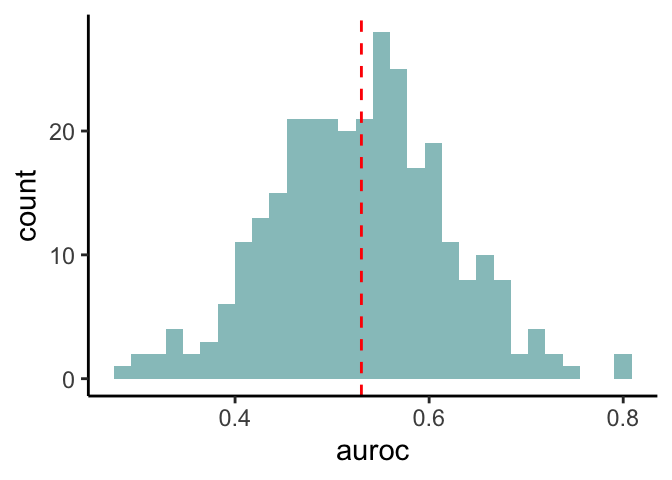

In [ ]:

aurocs |> 
  ggplot(aes(x = auroc)) +
  geom_histogram(fill = "#97C4C5") +
  geom_vline(xintercept = median(aurocs$auroc), linetype = "dashed", color = "red")


## Posterior Distribution

In [ ]:
pp <- aurocs |>
    select(outer_split_num, inner_split_num, auroc) |> 
    rename(id = outer_split_num,
           id2 = inner_split_num) |> 
    perf_mod(formula = statistic ~ 1 + (1 | id/id2),
             # prior_intercept = rstanarm::student_t(autoscale = TRUE),
             # prior = rstanarm::student_t(autoscale = TRUE),
             # transform = tidyposterior::logit_trans,  # for skewed & bounded AUC
             iter = 13000, chains = 4,
             adapt_delta = .99999999,
             # cores = 4, seed = 12345,
             family = gaussian)



SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.5e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.65 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:     1 / 13000 [  0%]  (Warmup)
Chain 1: Iteration:  1300 / 13000 [ 10%]  (Warmup)
Chain 1: Iteration:  2600 / 13000 [ 20%]  (Warmup)
Chain 1: Iteration:  3900 / 13000 [ 30%]  (Warmup)
Chain 1: Iteration:  5200 / 13000 [ 40%]  (Warmup)
Chain 1: Iteration:  6500 / 13000 [ 50%]  (Warmup)
Chain 1: Iteration:  6501 / 13000 [ 50%]  (Sampling)
Chain 1: Iteration:  7800 / 13000 [ 60%]  (Sampling)
Chain 1: Iteration:  9100 / 13000 [ 70%]  (Sampling)
Chain 1: Iteration: 10400 / 13000 [ 80%]  (Sampling)
Chain 1: Iteration: 11700 / 13000 [ 90%]  (Sampling)
Chain 1: Iteration: 13000 / 13000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 46.787 seconds (Warm-up)
Chain 1:                57.117 seconds (Sampling)
Ch

https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them.

https://mc-stan.org/misc/warnings.html#bfmi-low

Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess

Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#tail-ess

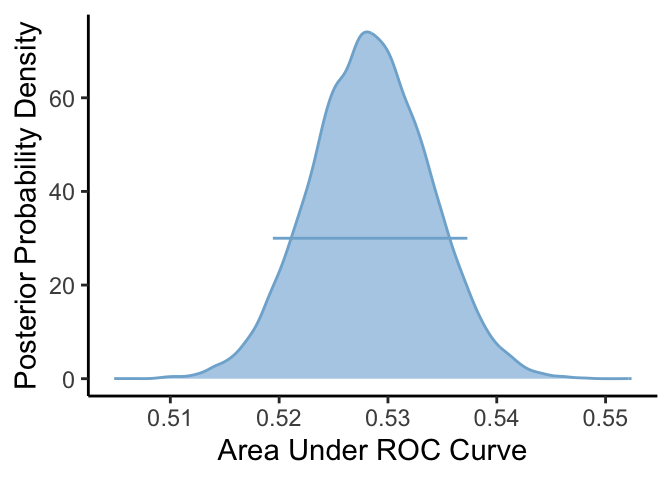

In [ ]:

pp_tidy <- pp |> 
  tidy(seed = 123)

ci_day <- pp_tidy |> 
  summary() |> 
  mutate(y = 30)

# vertical line for the median
pp_tidy |> 
  ggplot(aes(x = posterior)) + 
  geom_density(color = c("#80B1D3"), fill = c("#B3CFE8"), alpha = 1) +
  geom_segment(mapping = aes(y = y, yend = y, x = lower, xend = upper), color = c("#80B1D3"),
                data = ci_day) +
  ylab("Posterior Probability Density") +
  xlab("Area Under ROC Curve")


Add in curves for every outer fold.

In [ ]:
# roc_folds <- probs |> 
#   nest(.by = outer_split_num, .key = "preds") |> 
#   mutate(roc = map(preds, \(preds) roc_curve(preds, prob, 
#                                              truth = truth)))
# 
# fig_roc_folds <- roc_data |>   # plot region from full concatenated data
#   ggplot(aes(x = 1 - specificity, y = sensitivity)) + 
#   geom_abline(lty = 3) +
#   coord_fixed(xlim = c(0, 1), ylim = c(0, 1)) +
#   labs(x = "Specificity",
#        y = "Sensitivity") +
#   scale_x_continuous(breaks = seq(0,1,.25),
#     labels = sprintf("%.2f", seq(1,0,-.25))) +
#   theme(axis.title.x=element_blank(),
#         axis.text.x=element_blank(),
#         axis.ticks.x=element_blank())
#   
# for (i in 1:nrow(roc_folds)) {
#   fig_roc_folds <- fig_roc_folds +
#      geom_path(data = roc_folds$roc[[i]],
#                mapping = aes(x = 1 - specificity, y = sensitivity),
#                color = "gray")
# }
# 
# roc_data_smooth <- roc_data |> mutate(sensitivity = round(sensitivity, 4),
#                                       specificity = round(specificity, 4)) |>
#   group_by(sensitivity, specificity) |> 
#   summarise(.threshold = mean(.threshold)) 
# 
# #add full concatenated curve
# fig_roc_folds +
#      geom_path(data = roc_data_smooth,
#                mapping = aes(x = 1 - specificity, y = sensitivity, color = .threshold),
#                linewidth = 2) +
#     scale_color_gradient(low="blue", high="red")
